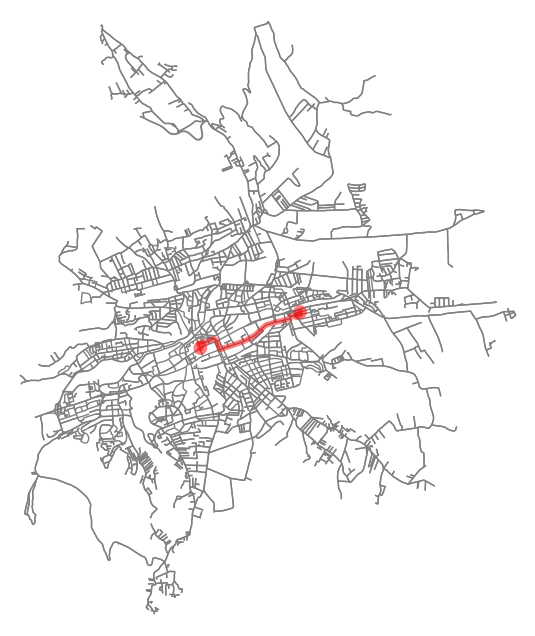

Estimated Travel Time: 4.01 minutes
Distance: 3.35 km


In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Load enriched graph
G = ox.load_graphml("../data/processed/cluj_enriched.graphml")

# Choose two random nodes (you can pick specific ones if needed)
# orig_node = list(G.nodes())[100]
# dest_node = list(G.nodes())[500]
orig_node = ox.distance.nearest_nodes(G, X=23.5899, Y=46.7712)  # Example: central Cluj
dest_node = ox.distance.nearest_nodes(G, X=23.6236, Y=46.7794)  # Another neighborhood


# Shortest path by travel time
route = nx.shortest_path(G, orig_node, dest_node, weight="travel_time")

# Plot the route
fig, ax = ox.plot_graph_route(
    G,
    route,
    route_linewidth=4,
    node_size=0,
    edge_color="gray",
    route_color="red",
    bgcolor="white"
)

# Optionally: Show route length and travel time
travel_time = sum(G[u][v][0]["travel_time"] for u, v in zip(route[:-1], route[1:]))
distance = sum(G[u][v][0]["length"] for u, v in zip(route[:-1], route[1:]))

print(f"Estimated Travel Time: {travel_time/60:.2f} minutes")
print(f"Distance: {distance/1000:.2f} km")
